# 03 — Train Emulators (Multi-z): Cluster Profiles

All cluster profile statistics: CGD, CGED, CPP, CTP, CEP, CEEP, CMP, CYP.
Multi-snapshot emulators (z ≤ 0.5, snapshots 415–624).
All models saved to `../models/<PROFILE>_multiz/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib.cm as cm
import os

from cosmo_hydro_emu.pca import *
from cosmo_hydro_emu.viz import *
from cosmo_hydro_emu.load_hacc import *
from cosmo_hydro_emu.emu import *
from cosmo_hydro_emu.gp import *
from cosmo_hydro_emu.snapshot_utils import SNAPSHOT_IDS, get_snapshot_redshifts

## Configuration

In [2]:
DirIn = '../data/400MPC_RUNS_5SG_2COSMO_PARAM/HAvoCC/'

start_sim_idx = 1
num_sims = 39
# Training-time PCA budget. Inference auto-syncs basis size from the saved
# pickle (via load_model_autosync), so this value is not constrained by the
# Inference YAML's exp_variance — pick whatever gives the best emulator.
exp_variance = 0.999

z_initial = 200

do_train = True

seed_mass_scale = 1e6
vkin_scale = 1e4
eps_scale = 1e1

## Load parameters

In [3]:
fileIn = '../data/FinalDesign.txt'
params_all = np.loadtxt(fileIn, delimiter=",", skiprows=1)
# Design CSV row K corresponds to RUN_K (both 0-indexed); row 0 = RUN000.
# With start_sim_idx=1, num_sims=39 the loaders read RUN001..RUN039; the
# matching slice is rows [1:40] = [start_sim_idx : start_sim_idx + num_sims].
params32 = params_all[start_sim_idx : start_sim_idx + num_sims]
params32[:, 2] /= seed_mass_scale
params32[:, 3] /= vkin_scale
params32[:, 4] /= eps_scale

print('params32 shape:', params32.shape)

# Train/test split
test_sim_indices = np.array([3, 11, 19, 27, 35])
train_sim_indices = np.array([i for i in range(num_sims) if i not in test_sim_indices])

params_train = params32[train_sim_indices]
params_test = params32[test_sim_indices]

print(f'Train: {len(train_sim_indices)} sims, Test: {len(test_sim_indices)} sims')

params32 shape: (39, 7)
Train: 34 sims, Test: 5 sims


## Snapshot setup

In [4]:
z_all, a_all = get_snapshot_redshifts(SNAPSHOT_IDS, z_initial=z_initial)

print(f'Number of snapshots: {len(SNAPSHOT_IDS)}')
print(f'Snapshot IDs: {SNAPSHOT_IDS}')
print(f'Redshift range: z = {z_all[-1]:.2f} to {z_all[0]:.2f}')
print(f'Scale factor range: a = {a_all[0]:.3f} to {a_all[-1]:.3f}')

Number of snapshots: 11
Snapshot IDs: [205, 224, 247, 275, 310, 355, 415, 479, 498, 567, 624]
Redshift range: z = 0.00 to 2.00
Scale factor range: a = 0.333 to 1.000


## Load all profile data

In [5]:
from cosmo_hydro_emu.load_hacc import read_profile_all_snaps

PROFILE_CONFIGS = {
    'CGD':  {'file_prefix': 'ClusterGasDensityProfile',         'label': 'Cluster Gas Density'},
    'CGED': {'file_prefix': 'ClusterGasElectronDensityProfile',  'label': 'Cluster Gas Electron Density'},
    'CPP':  {'file_prefix': 'ClusterGasPressureProfile',         'label': 'Cluster Gas Pressure'},
    'CTP':  {'file_prefix': 'ClusterGasTemperatureProfile',      'label': 'Cluster Gas Temperature'},
    'CEP':  {'file_prefix': 'ClusterGasEntropyProfile',          'label': 'Cluster Gas Entropy'},
    'CEEP': {'file_prefix': 'ClusterElectronEntropyProfile',     'label': 'Cluster Electron Entropy'},
    'CMP':  {'file_prefix': 'ClusterGasMetallicityProfile',      'label': 'Cluster Gas Metallicity'},
    'CYP':  {'file_prefix': 'ClusterGasYProfile',                'label': 'Cluster Compton-y (tSZ)'},
}

profile_data = {}
for short_name, config in PROFILE_CONFIGS.items():
    radius, arr = read_profile_all_snaps(DirIn, num_sims, SNAPSHOT_IDS,
                                          config['file_prefix'],
                                          start_sim_idx=start_sim_idx)
    profile_data[short_name] = arr
    print(f"{short_name}: {arr.shape}")

print(f"Radius bins: {radius.shape}")

CGD: (39, 11, 19)
CGED: (39, 11, 19)
CPP: (39, 11, 19)
CTP: (39, 11, 19)
CEP: (39, 11, 19)
CEEP: (39, 11, 19)
CMP: (39, 11, 19)
CYP: (39, 11, 19)
Radius bins: (19,)


## Radius cut

In [6]:
rlim1, rlim2 = mass_conds('CGD')  # same limits for all profiles
rad_cond = np.where((radius > rlim1) & (radius < rlim2))[0]
y_ind_profiles = radius[rad_cond]
print(f"Radius cut: {len(rad_cond)} bins in [{rlim1:.3f}, {rlim2:.3f}]")

Radius cut: 19 bins in [0.015, 2.750]


## Train all profiles

In [7]:
profile_z_start_idx = 6  # z <= 0.5
z_index_range = np.arange(profile_z_start_idx, len(SNAPSHOT_IDS))
profile_z_all = z_all[profile_z_start_idx:]

profile_models = {}

for short_name, config in PROFILE_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Training {short_name}: {config['label']}")
    print(f"{'='*60}")

    arr = profile_data[short_name]
    y_vals = arr[:, :, rad_cond]  # (num_sims, num_snaps, n_bins_cut)

    model_dir = f'../models/{short_name}_multiz/'

    if do_train:
        os.makedirs(model_dir, exist_ok=True)
        do_gp_train_multiple(
            model_dir=model_dir,
            p_train_all=params_train,
            y_vals_all=y_vals[train_sim_indices],
            y_ind_all=y_ind_profiles,
            z_index_range=z_index_range,
            exp_variance=exp_variance
        )

    model_list, data_list = load_model_multiple(
        model_dir=model_dir,
        p_train_all=params_train,
        y_vals_all=y_vals[train_sim_indices],
        y_ind_all=y_ind_profiles,
        z_index_range=z_index_range,
    )

    profile_models[short_name] = (model_list, data_list)
    print(f"  Loaded {len(model_list)} models for {short_name}")


Training CGD: Cluster Gas Density
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning:   0%|          | 0/50 [00:00<?, ?it/s]

Step size tuning: 100%|██████████| 50/50 [00:23<00:00,  2.14it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[1.74080373 1.01778212 1.24519213 0.45025278 0.2406496 ]
 [0.22435841 0.20253394 0.05092215 1.07345239 3.04870727]
 [0.3057007  4.38165025 0.52717195 0.88925088 7.31309025]
 [0.02517044 1.46127492 3.24407687 0.95385436 5.32199429]
 [1.76534068 1.54081674 2.61858701 0.93535438 1.29207391]
 [1.17137643 4.2762305  3.38623882 1.98293268 2.83117802]
 [0.70256076 2.00849437 0.06725524 0.95870676 3.2020824 ]
 [0.45380634 2.3304067  0.23306693 1.67704008 1.82311418]]
lamUz
[[1.45537692 1.20164408 1.12641652 2.03148663 1.62584477]]
lamWs
[[3744.48715553 4985.50745888 4675.55666314 5141.20066993 4357.76457562]]
lamWOs
[[1073.879417]]


MCMC sampling: 100%|██████████| 1000/1000 [00:36<00:00, 27.52it/s]


...

Model saved to ../models/CYP_multiz/multivariate_model_z_index9.pkl
Training complete for snapshot 9
Model saved at ../models/CYP_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:26<00:00,  1.86it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[0.35581572 0.23624405 0.10239865 1.05526859 1.17746754 0.31582843]
 [0.0557112  0.40713049 0.294069   0.66762146 0.14123227 0.36166078]
 [0.01127136 0.06082589 0.04618967 0.04924419 0.26898459 1.66419749]
 [0.01470354 0.30604483 0.01287536 1.03764597 0.06013989 0.09123274]
 [0.24034225 0.68422088 0.01994656 0.0682777  0.15445487 0.99694177]
 [0.235144   1.30237738 0.2825664  0.07173718 0.42642088 3.88593195]
 [2.19385297 2.22206982 3.0576644  1.91993208 0.82029764 2.40203152]
 [1.09355775 0.84435352 2.43777168 4.9561058  2.93607694 0.22722935]]
lamUz
[[2.1733802  1.92521932 1.97106641 1.73927364 2.29197159 1.7917636 ]]
lamWs
[[4161.046523   4013.54818396 4881.23824414 4491.29706775 4366.57144724
  4844.51445773]]
lamWOs
[[1019.17199156]]


MCMC sampling: 100%|██████████| 1000/1000 [00:23<00:00, 42.98it/s]

Model saved to ../models/CYP_multiz/multivariate_model_z_index10.pkl
Training complete for snapshot 10
Model saved at ../models/CYP_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Number of models loaded: 5 from: ../models/CYP_multiz/
  Loaded 5 models for CYP


## Validation at z=0 (all profiles)

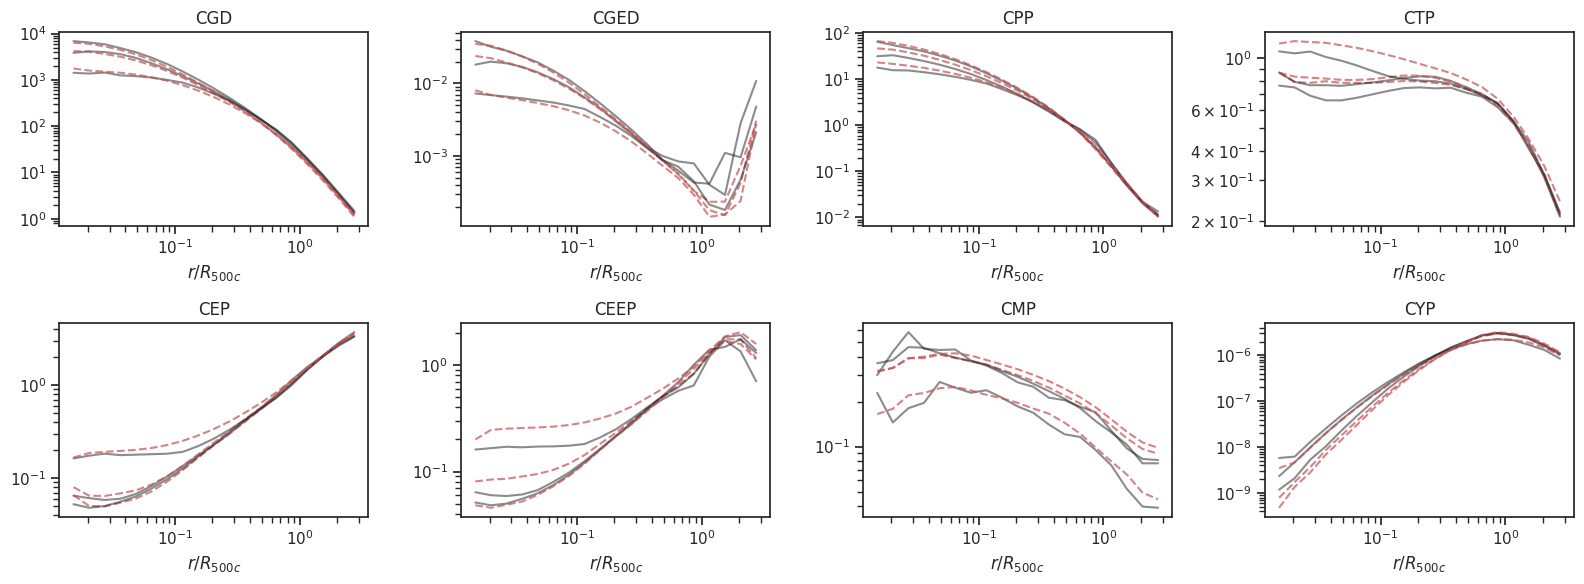

In [8]:
n_profiles = len(PROFILE_CONFIGS)
ncols = 4
nrows = (n_profiles + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for idx, (short_name, config) in enumerate(PROFILE_CONFIGS.items()):
    ax = axes[idx]
    model_list, data_list = profile_models[short_name]
    arr = profile_data[short_name]
    y_vals = arr[:, :, rad_cond]

    for t_idx in test_sim_indices[:3]:
        target = y_vals[t_idx, -1, :]  # z=0 (last snapshot)
        pred_mean, pred_quant = emulate(model_list[-1], params32[t_idx])
        ax.plot(y_ind_profiles, target, 'k-', alpha=0.5)
        ax.plot(y_ind_profiles, pred_mean[:, 0], 'r--', alpha=0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(short_name)
    ax.set_xlabel(r'$r/R_{500c}$')

for idx in range(len(PROFILE_CONFIGS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/profiles_multiz_validation.png', bbox_inches='tight')

## Redshift interpolation test

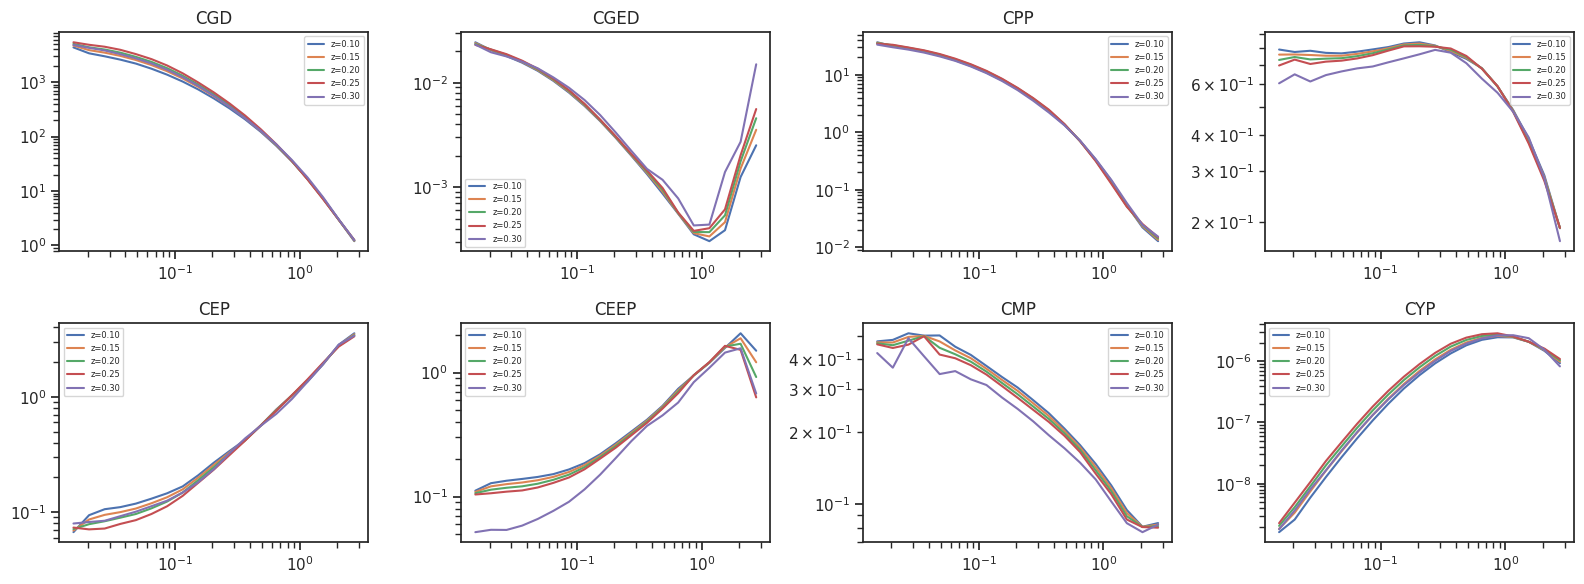

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

test_params = params32[test_sim_indices[0]]
z_grid = np.linspace(profile_z_all[-2], profile_z_all[1], 5)

for idx, (short_name, config) in enumerate(PROFILE_CONFIGS.items()):
    ax = axes[idx]
    model_list, data_list = profile_models[short_name]

    for z_target in z_grid:
        params_with_z = np.append(test_params, [z_target])[np.newaxis, :]
        pred_z, pred_z_err = emu_redshift(params_with_z, model_list, data_list, profile_z_all)
        ax.plot(y_ind_profiles, pred_z[:, 0], label=f'z={z_target:.2f}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(short_name)
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig('../plots/profiles_multiz_redshift_interp.png', bbox_inches='tight')

## Extra summary plots (ported from `_old/gp_SGC_misc_multiz.ipynb`)

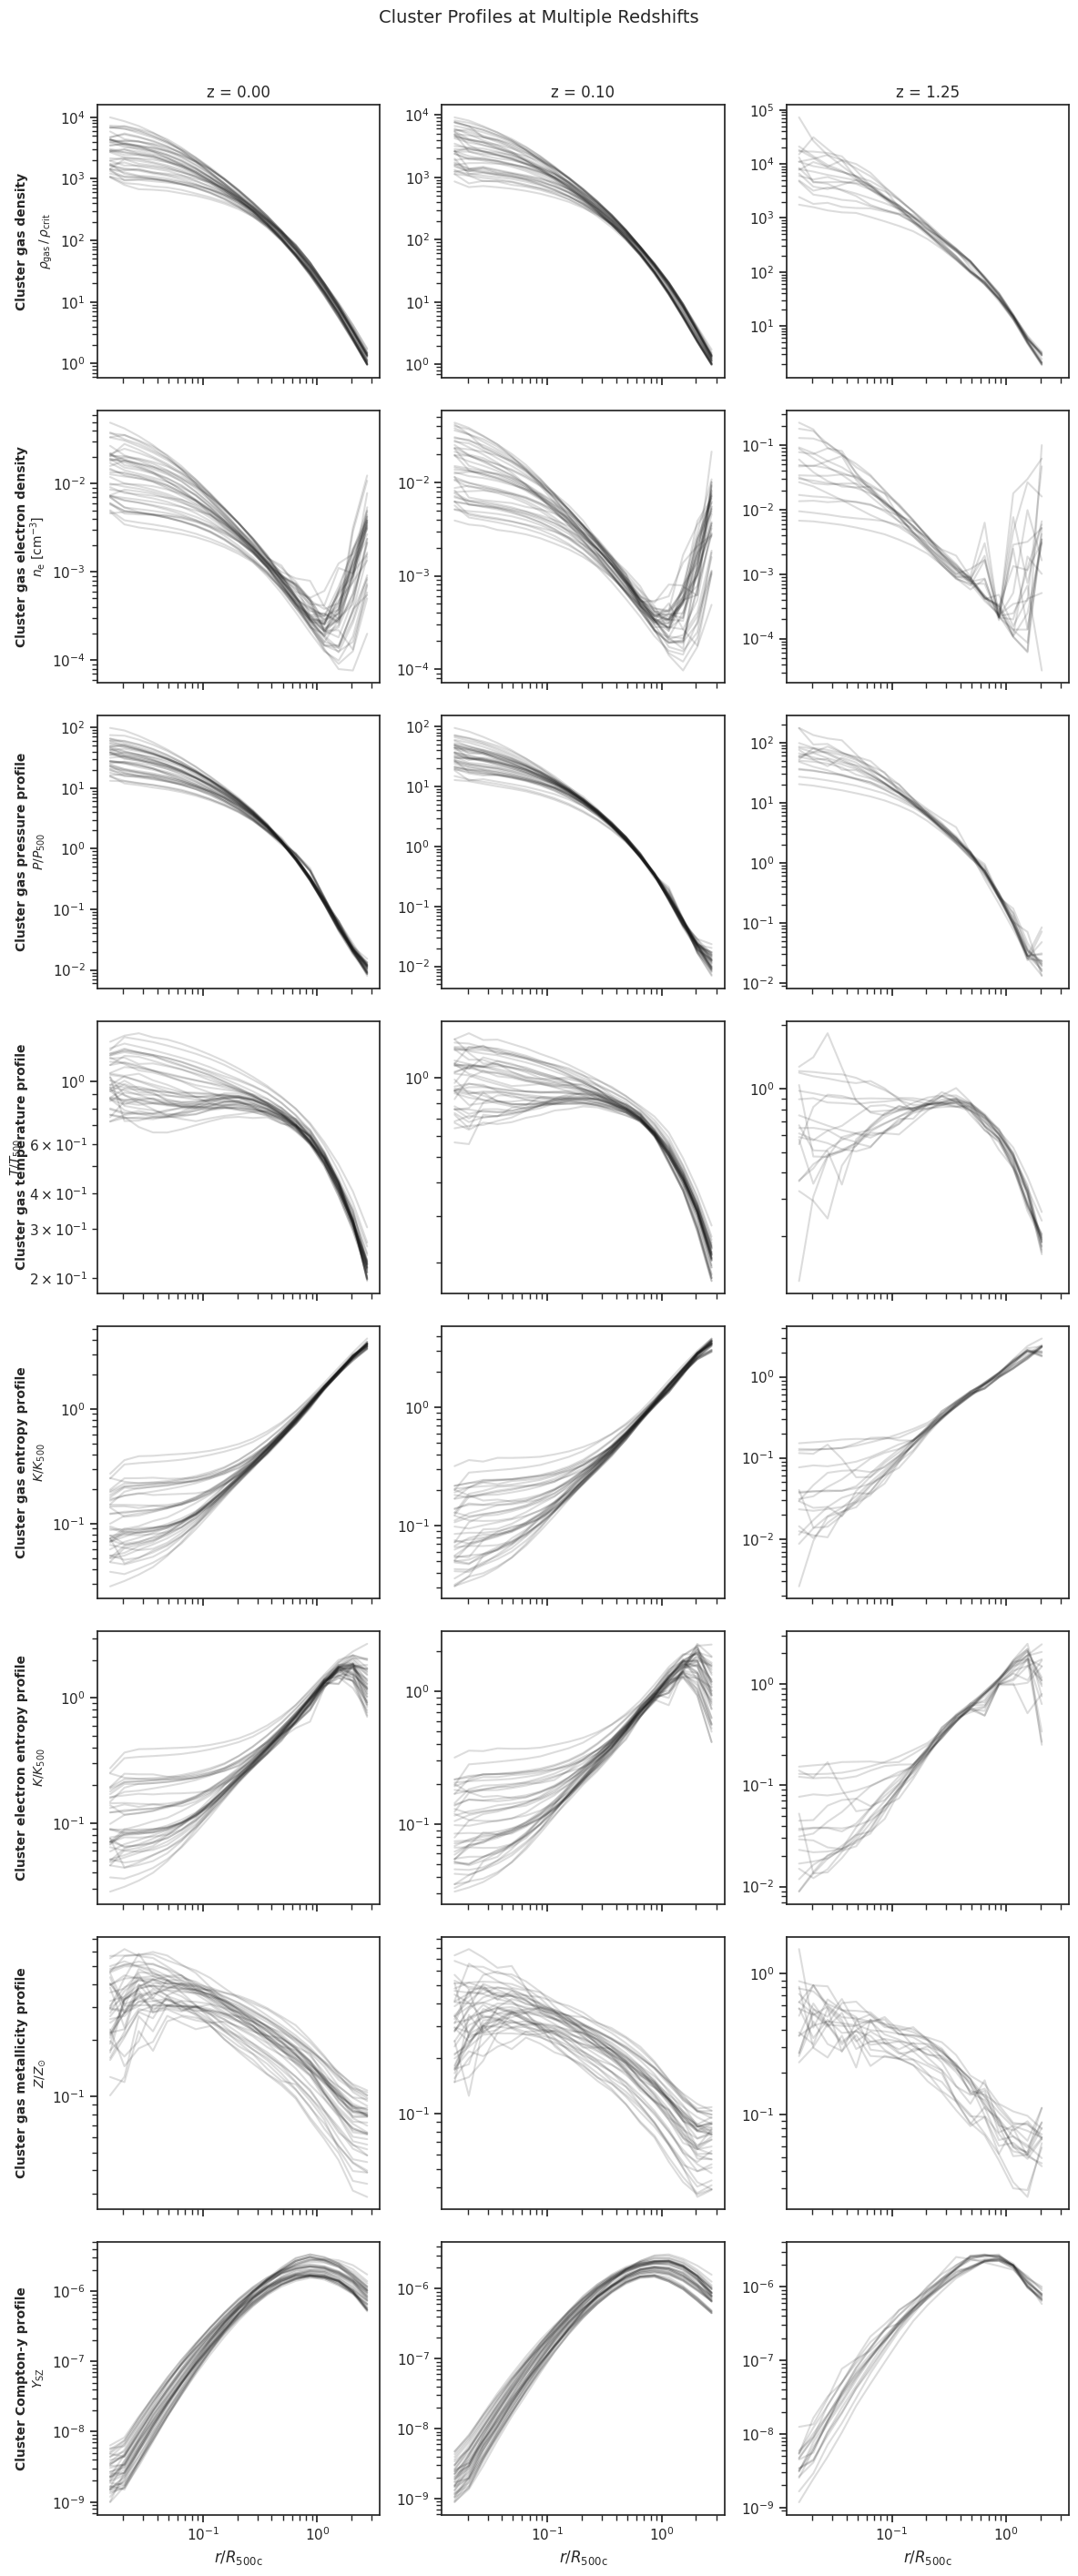

In [10]:
# profiles_all_multiz.png — every profile at 3 redshift snapshots
snap_indices_to_plot = [-1, -2, -8]  # z=0, slightly higher z, near profile_z_start_idx

n_profiles = len(PROFILE_CONFIGS)
n_snaps_plot = len(snap_indices_to_plot)

fig, axes = plt.subplots(n_profiles, n_snaps_plot,
                         figsize=(4*n_snaps_plot, 3.5*n_profiles),
                         sharex=True)

for row, (short_name, config) in enumerate(PROFILE_CONFIGS.items()):
    plt_str = plot_strings(short_name)
    arr = profile_data[short_name]

    for col, snap_idx in enumerate(snap_indices_to_plot):
        ax = axes[row, col]
        z_snap = z_all[snap_idx]

        for sim_i in range(num_sims):
            ax.plot(radius, arr[sim_i, snap_idx, :], 'k-', alpha=0.15)

        ax.set_xscale('log')
        ax.set_yscale('log')

        if row == 0:
            ax.set_title(f'z = {z_snap:.2f}', fontsize=12)
        if row == n_profiles - 1:
            ax.set_xlabel(plt_str[1])
        if col == 0:
            ax.set_ylabel(plt_str[2], fontsize=10)
            ax.annotate(plt_str[0], xy=(0, 0.5), xytext=(-60, 0),
                        textcoords='offset points', xycoords='axes fraction',
                        fontsize=10, rotation=90, va='center', ha='center',
                        fontweight='bold')

plt.suptitle('Cluster Profiles at Multiple Redshifts', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('../plots/profiles_all_multiz.png', bbox_inches='tight', dpi=150)
plt.show()

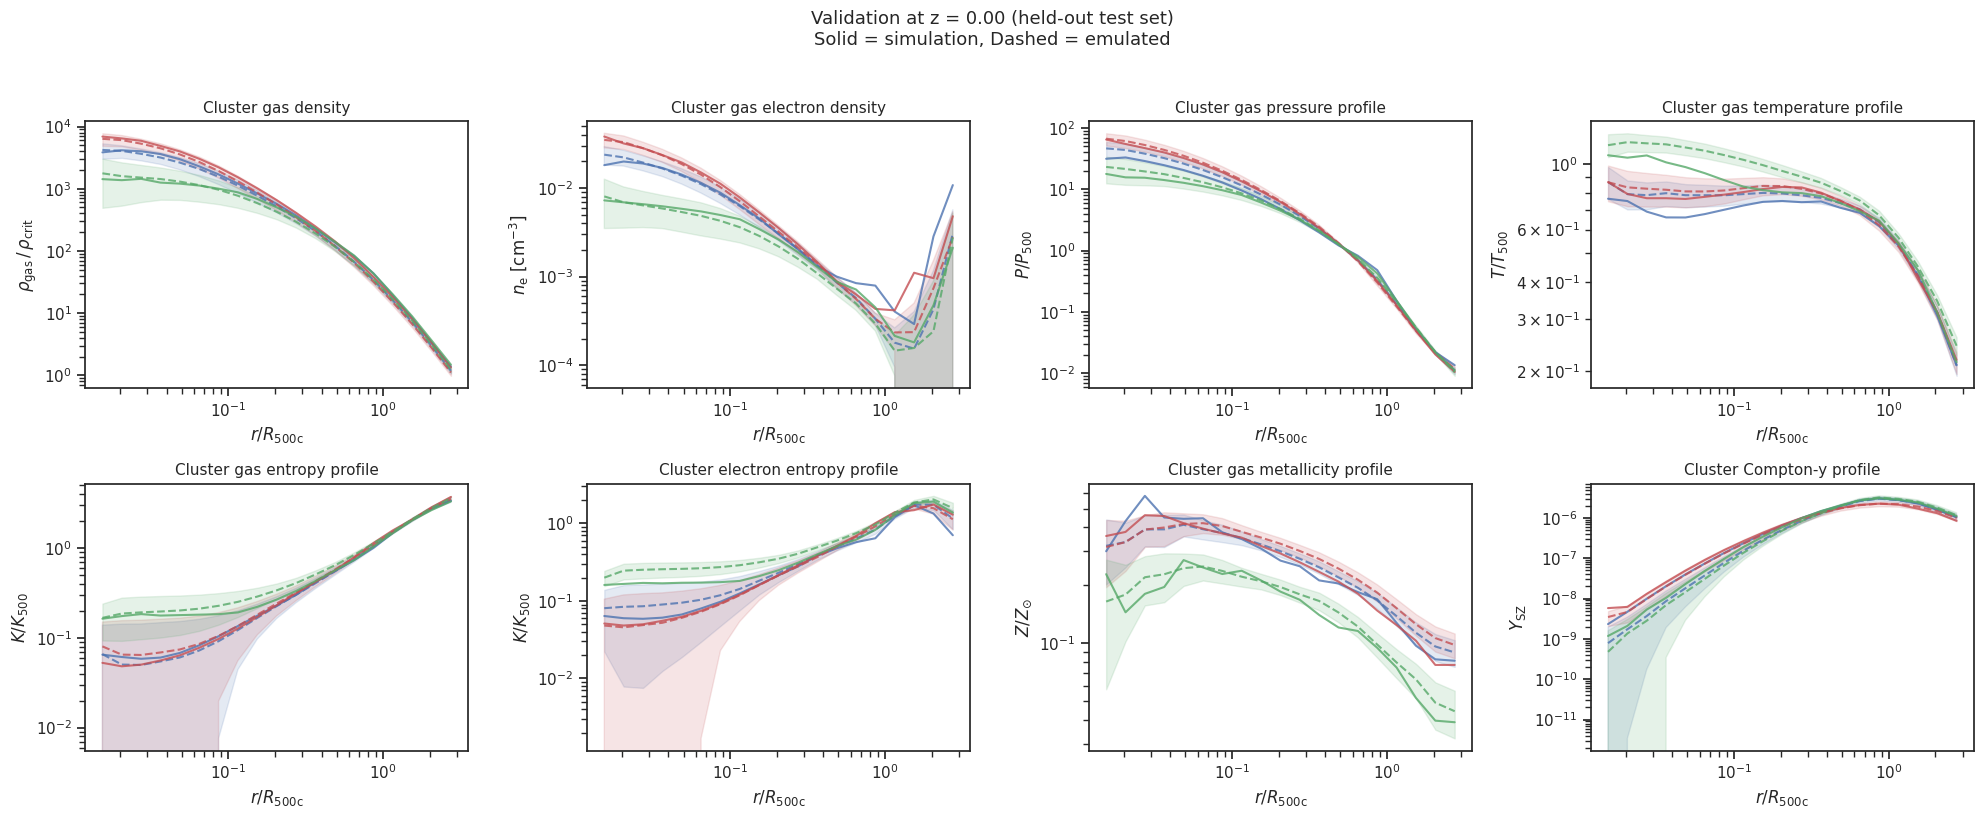

In [11]:
# profiles_all_validation_z0.png — 3 test sims, every profile, at z=0
n_profiles = len(PROFILE_CONFIGS)
ncols = 4
nrows = int(np.ceil(n_profiles / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = axes.flatten()

input_params = params_test[:3]
colors = ['b', 'r', 'g']

for idx, (short_name, config) in enumerate(PROFILE_CONFIGS.items()):
    ax = axes_flat[idx]
    model_list, data_list = profile_models[short_name]
    plt_str = plot_strings(short_name)

    arr = profile_data[short_name]
    y_vals = arr[:, :, rad_cond]
    target_vals = y_vals[test_sim_indices[:3], -1, :]  # last snap = z=0

    pred_mean, pred_quant = emulate(model_list[-1], input_params)

    # pred_quant may be std (2D) or quantile (3D); fold both to a band
    pq = np.asarray(pred_quant)
    band_lo = pred_mean - 1.6449 * pq if pq.ndim == 2 else pq[..., 0]
    band_hi = pred_mean + 1.6449 * pq if pq.ndim == 2 else pq[..., 1]

    for j in range(pred_mean.shape[1]):
        ax.plot(y_ind_profiles, target_vals[j], c=colors[j], ls='-', alpha=0.8)
        ax.plot(y_ind_profiles, pred_mean[:, j], c=colors[j], ls='--', alpha=0.8)
        ax.fill_between(y_ind_profiles, band_lo[:, j], band_hi[:, j],
                        color=colors[j], alpha=0.15)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(plt_str[0], fontsize=11)
    ax.set_xlabel(plt_str[1]); ax.set_ylabel(plt_str[2])

for idx in range(n_profiles, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(f'Validation at z = {z_all[-1]:.2f} (held-out test set)\n'
             f'Solid = simulation, Dashed = emulated', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../plots/profiles_all_validation_z0.png', bbox_inches='tight', dpi=150)
plt.show()

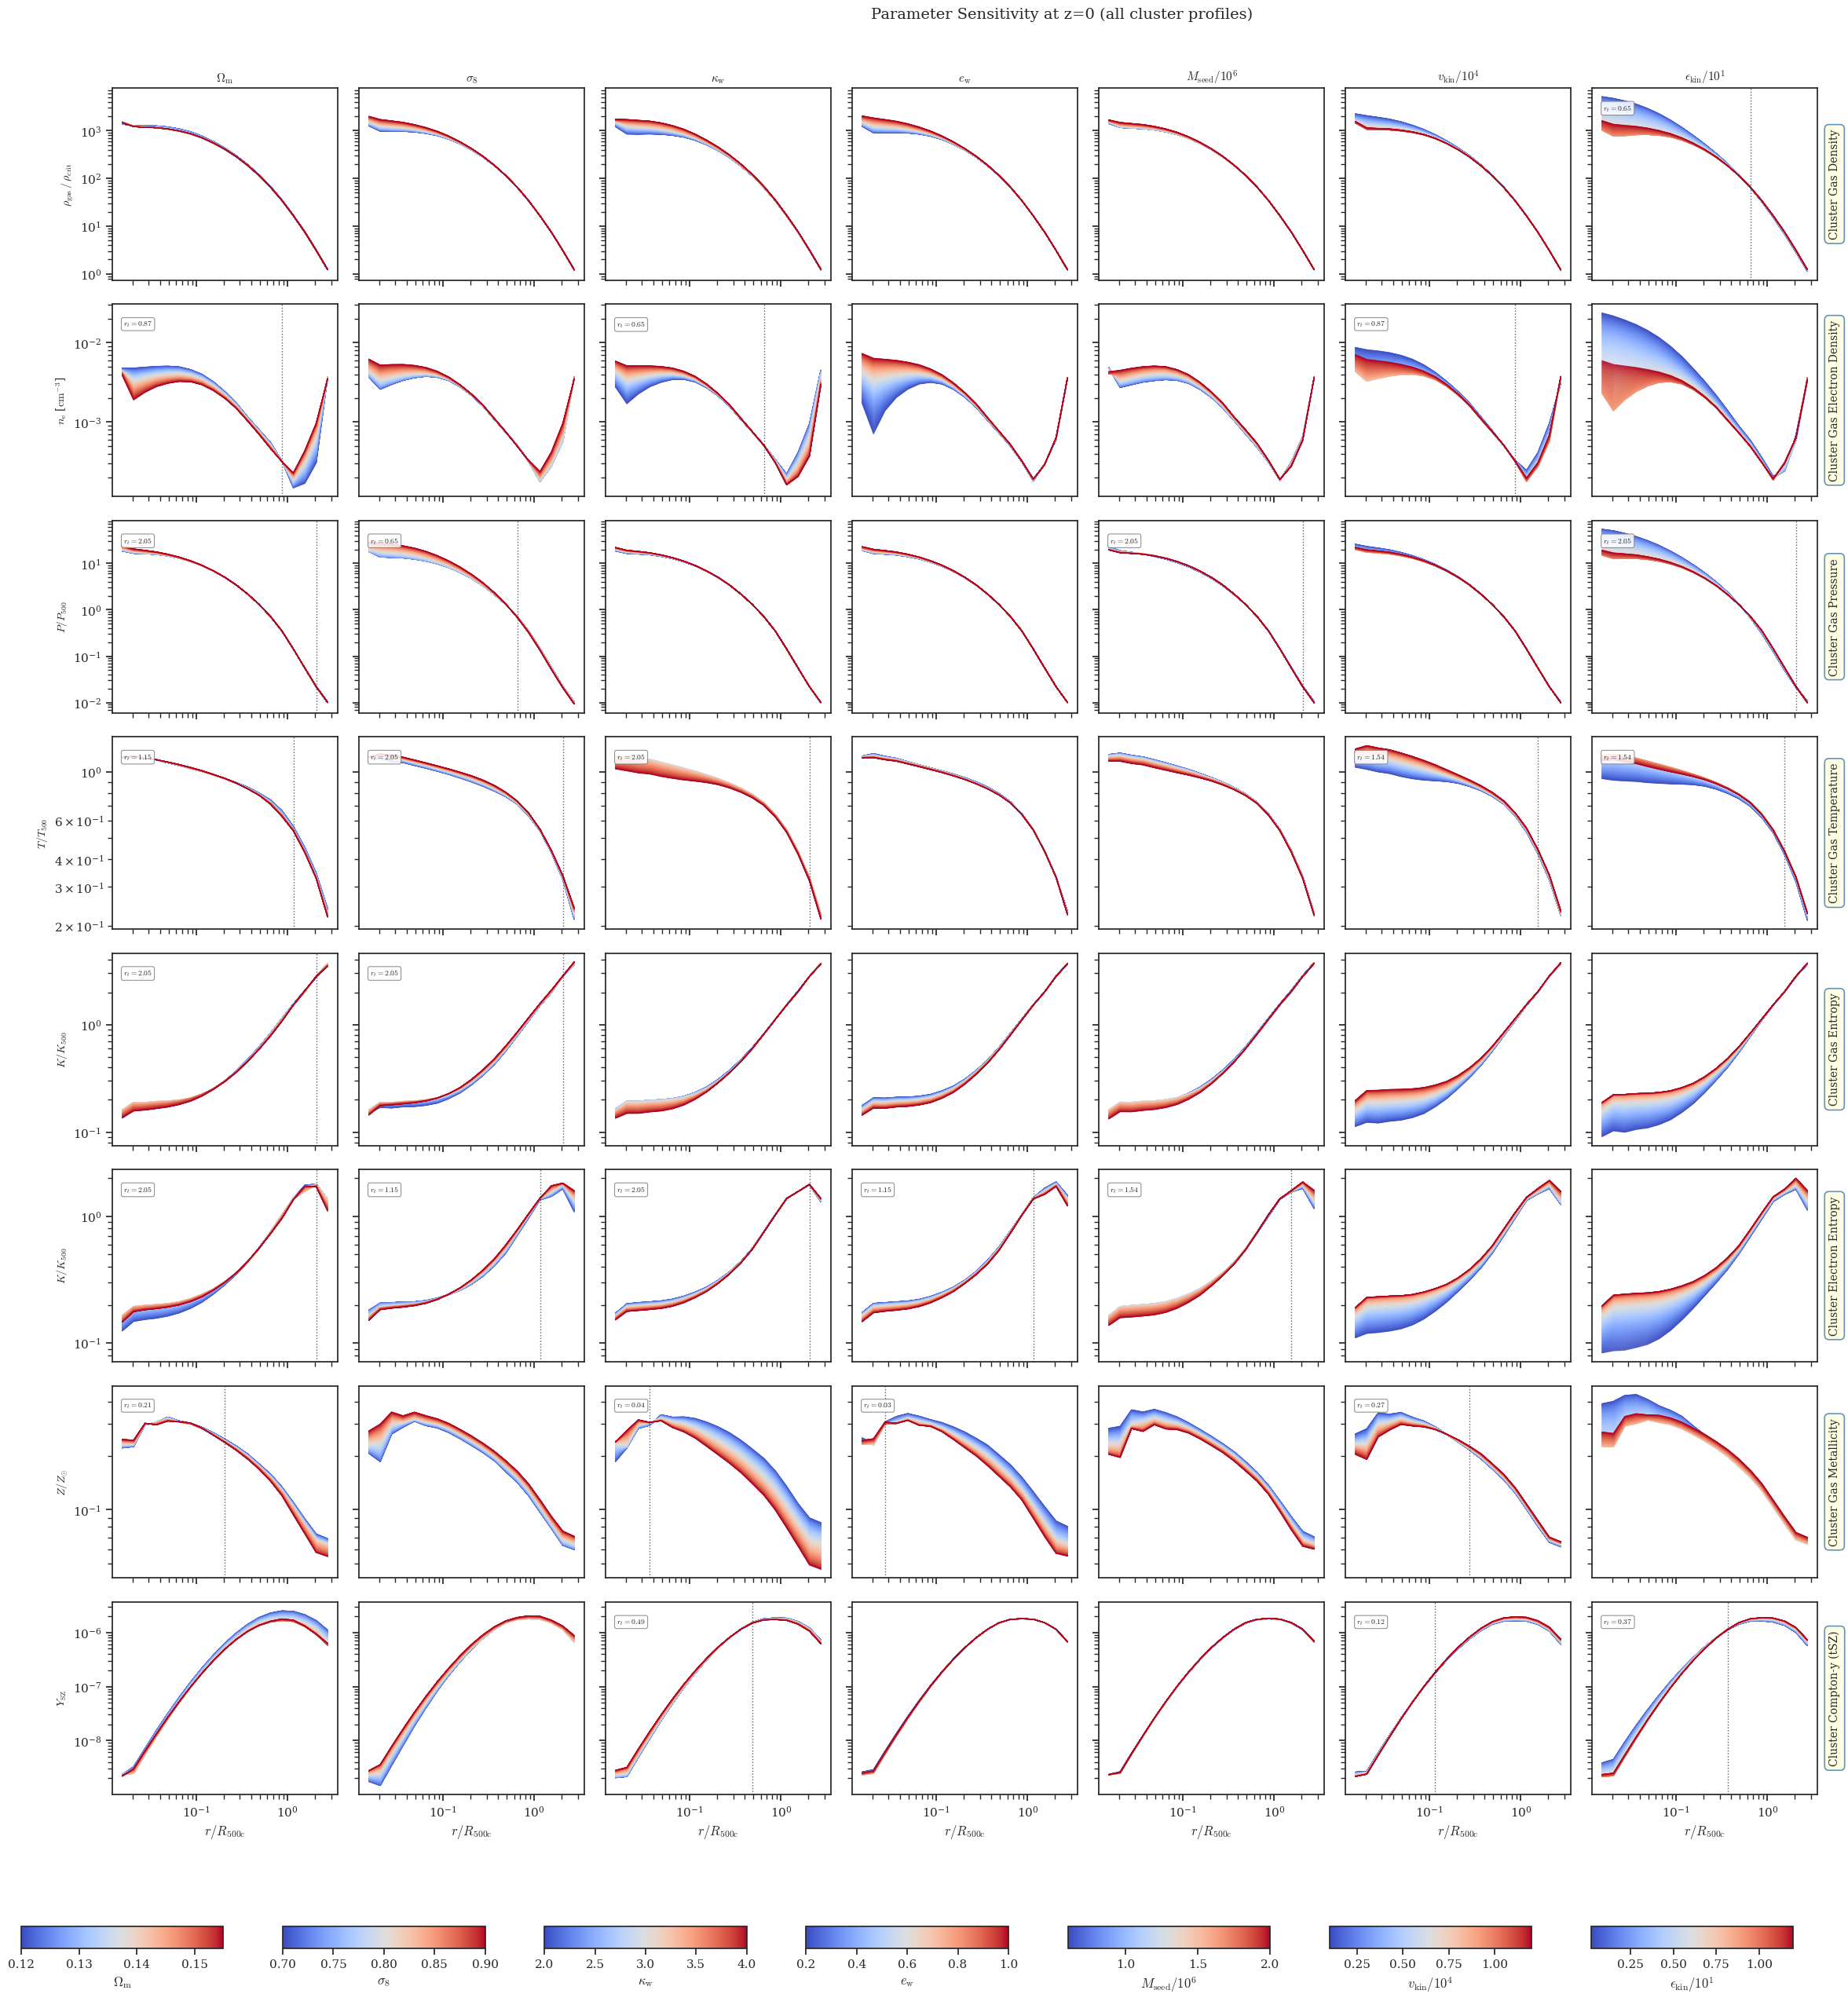

In [12]:
# profiles_all_sensitivity_z0.png — per-param sensitivity at z=0 for every profile
import matplotlib.colors as mcolors

plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

numPlots = 300
allMax  = np.max(params32, axis=0)
allMin  = np.min(params32, axis=0)
allMean = np.mean(params32, axis=0)

# Order: cosmology first (omega_m, sigma_8), then subgrid
params_to_vary = [5, 6, 0, 1, 2, 3, 4]
param_labels   = [PARAM_NAME[i] for i in params_to_vary]

PROFILE_FULL_NAMES = {k: v['label'] for k, v in PROFILE_CONFIGS.items()}

n_profiles = len(PROFILE_CONFIGS)
n_params   = len(params_to_vary)

separation_threshold = 0.05  # frac spread that defines "separation"

fig, axes = plt.subplots(n_profiles, n_params,
                         figsize=(3.5*n_params + 2, 3*n_profiles),
                         sharex=True, sharey='row')
fig.subplots_adjust(right=0.88)

cmap = cm.coolwarm
bbox_props       = dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                        alpha=0.85, edgecolor='steelblue', lw=1.2)
trans_bbox_props = dict(boxstyle='round,pad=0.25', facecolor='white',
                        alpha=0.85, edgecolor='gray', lw=0.8)

for row, (short_name, config) in enumerate(PROFILE_CONFIGS.items()):
    model_list, data_list = profile_models[short_name]
    plt_str = plot_strings(short_name)

    for col, paramNo in enumerate(params_to_vary):
        ax = axes[row, col]
        para_range = np.linspace(allMin[paramNo], allMax[paramNo], numPlots)
        norm = mcolors.Normalize(vmin=allMin[paramNo], vmax=allMax[paramNo])

        all_preds = np.zeros((numPlots, len(y_ind_profiles)))
        for plotID in range(numPlots):
            para_plot = np.copy(allMean)
            para_plot[paramNo] = para_range[plotID]
            pred, _ = emulate(model_list[-1], para_plot)
            pred_flat = pred.flatten()
            all_preds[plotID] = pred_flat
            ax.plot(y_ind_profiles, pred_flat, lw=0.8,
                    color=cmap(norm(para_range[plotID])), alpha=0.7)

        pred_mean   = np.mean(all_preds, axis=0)
        pred_spread = np.max(all_preds, axis=0) - np.min(all_preds, axis=0)
        frac_spread = pred_spread / np.abs(pred_mean)

        # rightmost radial bin where lines are still converged
        transition_idx = None
        for i in range(len(y_ind_profiles) - 1, -1, -1):
            if frac_spread[i] < separation_threshold:
                transition_idx = i
                break
        if transition_idx is not None and transition_idx < len(y_ind_profiles) - 1:
            r_trans = y_ind_profiles[transition_idx]
            ax.axvline(r_trans, color='k', ls=':', lw=1.0, alpha=0.7)
            ax.text(0.05, 0.92, f'$r_t = {r_trans:.2f}$',
                    transform=ax.transAxes, fontsize=7,
                    va='top', ha='left', bbox=trans_bbox_props)

        ax.set_xscale('log'); ax.set_yscale('log')
        if row == 0: ax.set_title(param_labels[col], fontsize=11)
        if row == n_profiles - 1: ax.set_xlabel(plt_str[1])
        if col == 0: ax.set_ylabel(plt_str[2], fontsize=10)
        if col == n_params - 1:
            ax.text(1.05, 0.5, PROFILE_FULL_NAMES[short_name],
                    transform=ax.transAxes, fontsize=10, va='center', ha='left',
                    rotation=90, bbox=bbox_props)

# colorbars at the bottom, one per param column
cb_width = 0.8 / n_params
for col, paramNo in enumerate(params_to_vary):
    norm = mcolors.Normalize(vmin=allMin[paramNo], vmax=allMax[paramNo])
    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cb_left = 0.0 + col * (0.88 / n_params)
    cax = fig.add_axes([cb_left, -0.02, cb_width * 0.85, 0.012])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label(PARAM_NAME[paramNo], fontsize=12)

fig.suptitle('Parameter Sensitivity at z=0 (all cluster profiles)', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0.03, 0.88, 1.0])
plt.savefig('../plots/profiles_all_sensitivity_z0.png', bbox_inches='tight', dpi=150)
plt.show()

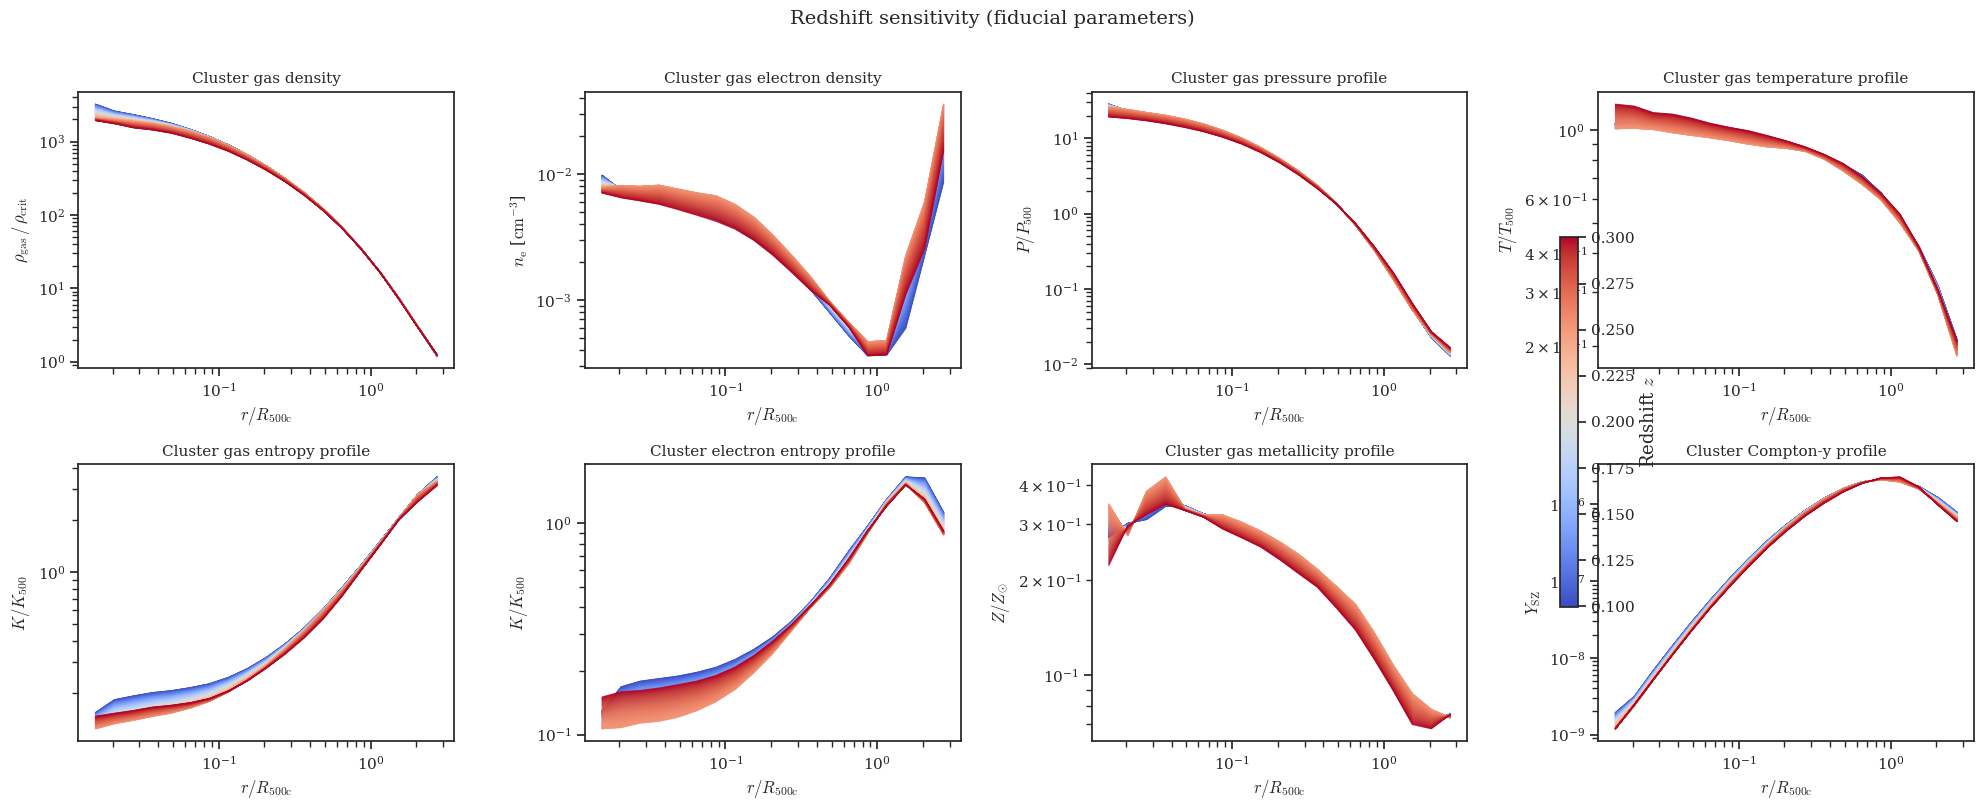

In [13]:
# profiles_all_z_sensitivity.png — redshift sensitivity at fiducial params, every profile
import matplotlib.colors as mcolors
allMean = np.mean(params32, axis=0)
numPlots = 300
cmap = cm.coolwarm

n_profiles = len(PROFILE_CONFIGS)
ncols = 4
nrows = int(np.ceil(n_profiles / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = axes.flatten()

z_grid = np.linspace(profile_z_all[-2], profile_z_all[1], numPlots)
norm_z = mcolors.Normalize(vmin=z_grid.min(), vmax=z_grid.max())

for idx, (short_name, config) in enumerate(PROFILE_CONFIGS.items()):
    ax = axes_flat[idx]
    model_list, data_list = profile_models[short_name]
    plt_str = plot_strings(short_name)

    for z_val in z_grid:
        input_with_z = np.hstack([allMean.reshape(1, -1), np.array([[z_val]])])
        pred, _ = emu_redshift(input_with_z, model_list, data_list, profile_z_all)
        ax.plot(y_ind_profiles, pred.flatten(), lw=0.8,
                color=cmap(norm_z(z_val)), alpha=0.7)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(plt_str[0], fontsize=11)
    ax.set_xlabel(plt_str[1]); ax.set_ylabel(plt_str[2])

for idx in range(n_profiles, len(axes_flat)):
    axes_flat[idx].set_visible(False)

sm = cm.ScalarMappable(norm=norm_z, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes_flat[:n_profiles].tolist(), shrink=0.6, pad=0.02)
cbar.set_label(r'Redshift $z$', fontsize=13)

fig.suptitle('Redshift sensitivity (fiducial parameters)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../plots/profiles_all_z_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()